# 💡 RAG Agent with LLM-Powered Document Grading & Web Fallback

In [12]:

from langgraph.graph import StateGraph, START, END
from langchain.document_loaders.csv_loader import CSVLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.vectorstores import FAISS
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain.schema import Document
from typing import List
from typing_extensions import TypedDict
from IPython.display import Markdown, display
from langchain_tavily import TavilySearch
from langgraph.prebuilt import create_react_agent
from langchain_core.messages import SystemMessage, HumanMessage
from pydantic import BaseModel, Field
import json
from IPython.display import Image, display


In [2]:

class GraphState(TypedDict):
    question: str
    generation: str
    documents: List[Document]
    web_documents: List[str]
    source: str
    retriever: object


### 📥 retrieve_CSV
Loads the CSV, splits content, builds the FAISS vectorstore, and returns the retriever.

In [3]:

def retrieve_CSV(state: GraphState) -> GraphState:
    loader = CSVLoader(file_path="./Dublin_Restaurants_2025.csv")
    docs = loader.load()

    text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
    splits = text_splitter.split_documents(docs)

    vectorstore = FAISS.from_documents(splits, OpenAIEmbeddings())
    retriever = vectorstore.as_retriever(search_type="similarity", search_kwargs={"k": 4})

    return {
        "question": state["question"],
        "retriever": retriever
    }


### 🔎 check_docs_exist
Retrieves documents from the retriever for a given question.

In [4]:

def check_docs_exist(state: GraphState) -> GraphState:
    query = state["question"]
    retriever = state["retriever"]
    docs = retriever.invoke(query)

    print("\n🧾 Retrieved docs:")
    for doc in docs:
        print("-", doc.page_content)

    return {
        **state,
        "documents": docs
    }


### 🧮 grade_documents
Uses an LLM with structured output to determine if each document is relevant to the question.

In [5]:

class GradeDocuments(BaseModel):
    binary_score: str = Field(description="Documents are relevant to the question, 'yes' or 'no'")

grade_documents_llm = ChatOpenAI(model="gpt-4", temperature=0).with_structured_output(GradeDocuments)
grade_documents_system_prompt = """You are a grader assessing relevance of a retrieved document to a user question.
If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant.
It does not need to be a stringent test. The goal is to filter out erroneous retrievals.
Give a binary score 'yes' or 'no' to indicate whether the document is relevant."""

def grade_documents(state: GraphState) -> GraphState:
    question = state["question"]
    documents = state.get("documents", [])
    filtered_docs = []

    for doc in documents:
        prompt = f"QUESTION: {question}\nDOCUMENT: {doc.page_content}\nIs this document relevant?"
        response = grade_documents_llm.invoke(
            [SystemMessage(content=grade_documents_system_prompt), HumanMessage(content=prompt)]
        )
        if response.binary_score.strip().lower() == "yes":
            filtered_docs.append(doc)

    return {
        **state,
        "documents": filtered_docs,
        "source": "rag" if filtered_docs else "web"
    }


/Users/bogdan.birgu/MySandboxes/LangChain/My_Agent/.venv/lib/python3.12/site-packages/langchain_openai/chat_models/base.py:1857: UserWarning: Cannot use method='json_schema' with model gpt-4 since it doesn't support OpenAI's Structured Output API. You can see supported models here: https://platform.openai.com/docs/guides/structured-outputs#supported-models. To fix this warning, set `method='function_calling'. Overriding to method='function_calling'.
  warnings.warn(


### 🧠 RAG Prompt
This prompt guides the LLM to generate answers strictly from retrieved documents.

In [ ]:

RAG_PROMPT = """You are an assistant for restaurant recommendations in Dublin, Ireland.

Use the following pieces of retrieved context to answer the user's question.
Only use information from the context. If the answer cannot be found in the context, say: 'I couldn't find that information in our local guide.'

Context:
{context}

Question:
{question}

Answer:"""


### 🧾 generate_response
Uses the RAG prompt and retrieved documents to generate an answer with an LLM.

In [ ]:

from langchain_core.messages import HumanMessage

def generate_response(state: GraphState) -> GraphState:
    print("✅ Generating from documents...")

    docs = state.get("documents", [])
    if not docs:
        return {**state, "generation": "No relevant documents found."}

    context = "\n\n".join([doc.page_content for doc in docs])
    question = state["question"]
    prompt = RAG_PROMPT.format(context=context, question=question)

    llm = ChatOpenAI(model="gpt-4", temperature=0)
    response = llm.invoke([HumanMessage(content=prompt)])

    return {
        **state,
        "generation": response.content
    }


### 🌐 retrieve_web
Uses a ReAct agent with the Tavily tool to answer the question with web search.

In [7]:

llm = ChatOpenAI(model="gpt-4", temperature=0)
tavily = TavilySearch(max_results=3)
agent = create_react_agent(llm, [tavily])

def retrieve_web(state: GraphState) -> GraphState:
    query = state["question"]
    web_results = []

    for step in agent.stream({"messages": query}, stream_mode="values"):
        message = step["messages"][-1]
        if message.type in ["tool", "tool_result", "llm"]:
            web_results.append(message.content)

    return {
        **state,
        "web_documents": web_results
    }


### 🧠 generate_web_response
Parses and formats Tavily web search results into a user-friendly answer.

In [8]:

def generate_web_response(state: GraphState) -> GraphState:
    web_raw = state.get("web_documents", [])
    if not web_raw:
        return {**state, "generation": "No web content available."}

    try:
        parsed = json.loads(web_raw[-1])
        results = parsed.get("results", [])
    except Exception:
        return {**state, "generation": "Failed to parse web results."}

    output = f"### 🌐 Web Search Results for: *{state['question']}*\n\n"
    for r in results[:3]:
        title = r.get("title", "Untitled")
        summary = r.get("content", "").strip()
        url = r.get("url", "")
        output += f"• **{title}**\n  > {summary}\n  🔗 [Source]({url})\n\n"

    return {
        **state,
        "generation": output.strip()
    }


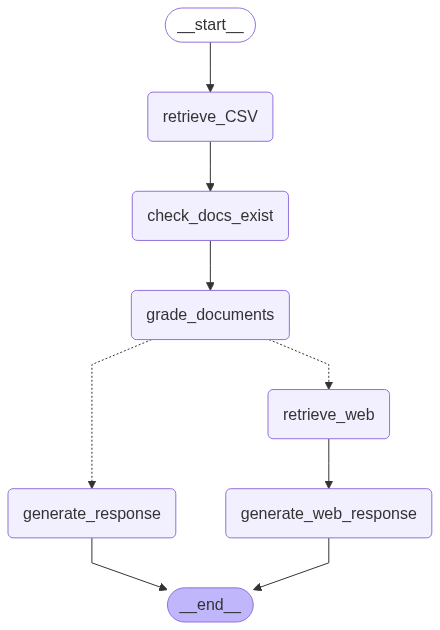

In [14]:

rag_workflow = StateGraph(GraphState)
rag_workflow.add_node("retrieve_CSV", retrieve_CSV)
rag_workflow.add_node("check_docs_exist", check_docs_exist)
rag_workflow.add_node("grade_documents", grade_documents)
rag_workflow.add_node("generate_response", generate_response)
rag_workflow.add_node("retrieve_web", retrieve_web)
rag_workflow.add_node("generate_web_response", generate_web_response)

rag_workflow.add_edge(START, "retrieve_CSV")
rag_workflow.add_edge("retrieve_CSV", "check_docs_exist")
rag_workflow.add_edge("check_docs_exist", "grade_documents")

rag_workflow.add_conditional_edges(
    "grade_documents",
    lambda state: "generate_response" if state["source"] == "rag" else "retrieve_web",
    {
        "generate_response": "generate_response",
        "retrieve_web": "retrieve_web"
    }
)

rag_workflow.add_edge("generate_response", END)
rag_workflow.add_edge("retrieve_web", "generate_web_response")
rag_workflow.add_edge("generate_web_response", END)

rag_app = rag_workflow.compile()
display(Image(rag_app.get_graph().draw_mermaid_png()))


In [18]:

from IPython.display import Markdown
result = rag_app.invoke({"question": "Any recommendations for a Italian restaurant in Dublin,Ireland ?"})
Markdown(result["generation"])



🧾 Retrieved docs:
- Position: 21
Restaurant: Etto
Description: Stylish Michelin-Guide Italian spot near St Stephen’s Green with well-priced fine food.
- Position: 17
Restaurant: Restaurant Patrick Guilbaud
Description: Dublin’s flagship fine dining spot with €245 tasting menu.
- Position: 22
Restaurant: Glovers Alley
Description: Elegant dining overlooking St Stephen’s Green with €155 tasting and €75 lunch menus.
- Position: 20
Restaurant: Mr Fox
Description: Contemporary Irish-French cuisine with a €93 tasting menu and 4.7-star reviews.


### 🍽️ Top Restaurant Recommendations from Our Local Guide

**1. Etto** (# 21)  
_Stylish Michelin-Guide Italian spot near St Stephen’s Green with well-priced fine food._